# Skenario 4 — Embedded Method (Feature Importance)

**Tujuan**: Seleksi fitur menggunakan importance yang **built-in** dalam proses training model.

### Metode yang Digunakan
1. **Random Forest Feature Importance** — berdasarkan **mean decrease in impurity (Gini)**. Setiap kali fitur digunakan untuk split di decision tree, impurity berkurang. Fitur yang sering menghasilkan split dengan penurunan impurity besar dianggap penting.
2. **XGBoost Feature Importance** — berdasarkan **gain** (total improvement in loss function). XGBoost menggunakan boosting bertahap, sehingga importance-nya lebih fokus pada fitur yang memperbaiki prediksi secara inkremental.

### Perbedaan RF vs XGBoost Importance
- RF: tree tumbuh **paralel** (bagging) → importance cenderung lebih **merata** karena setiap tree independen
- XGBoost: tree tumbuh **sekuensial** (boosting) → importance lebih **tajam** karena tree berikutnya fokus memperbaiki error tree sebelumnya

### Embedded vs Filter vs Wrapper
- **Filter** (B.2): menilai fitur secara statistik, independen dari model
- **Wrapper** (B.3): menilai fitur dengan iterasi training model berulang kali
- **Embedded** (B.4): importance diperoleh **gratis** dari satu kali training — lebih efisien dari wrapper, lebih model-aware dari filter

In [1]:
# Ubah working directory ke root project agar path data sesuai
import os
if os.path.basename(os.getcwd()) == 'src':
    os.chdir('..')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Library berhasil di-import ✅')

Library berhasil di-import ✅


## 1. Load Data

In [3]:
X_train = pd.read_csv('preprocessed_data/X_train.csv')
X_test  = pd.read_csv('preprocessed_data/X_test.csv')
y_train = pd.read_csv('preprocessed_data/y_train.csv').squeeze()
baseline    = pd.read_csv('baseline_results.csv', index_col='model')
filter_res  = pd.read_csv('filter_method_results.csv', index_col='model')
wrapper_res = pd.read_csv('wrapper_method_results.csv', index_col='model')

LABEL_NAMES = {0:'Dewasa Muda (18-35)', 1:'Dewasa (36-53)', 2:'Paruh Baya (54-71)', 3:'Lansia (72-89)'}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')

X_train: (3000, 35) | y_train: (3000,)


---
## 2. Random Forest Feature Importance
Latih RF pada seluruh data training, lalu ambil `feature_importances_` yang dihitung secara otomatis dari rata-rata penurunan impurity di seluruh tree.

In [4]:
# Latih RF untuk mendapatkan feature importance
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

rf_imp['rank'] = range(1, len(rf_imp)+1)
print('=== RF Feature Importance (top 15) ===')
print(rf_imp.head(15)[['rank','feature','importance']].to_string(index=False))

=== RF Feature Importance (top 15) ===
 rank                     feature  importance
    1        Bone Density (g/cm²)    0.247740
    2            Vision Sharpness    0.177284
    3        Hearing Ability (dB)    0.087576
    4                 BP_Systolic    0.068361
    5                BP_Diastolic    0.053383
    6          Cognitive Function    0.040237
    7   Cholesterol Level (mg/dL)    0.039535
    8 Blood Glucose Level (mg/dL)    0.036205
    9          Pollution Exposure    0.024730
   10                         BMI    0.024202
   11                Sun Exposure    0.024151
   12               Stress Levels    0.024104
   13                 Weight (kg)    0.023191
   14                 Height (cm)    0.022787
   15             Education Level    0.009904


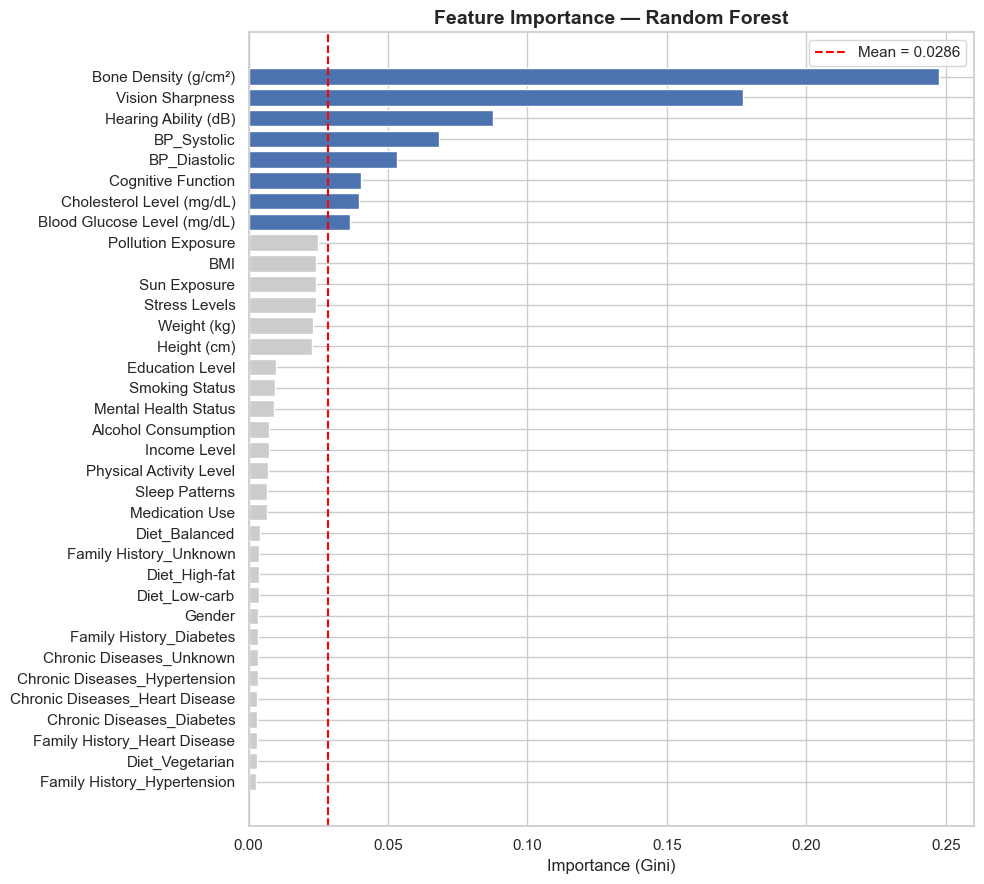

In [5]:
# Visualisasi RF importance
fig, ax = plt.subplots(figsize=(10, 9))
data = rf_imp.sort_values('importance', ascending=True)
threshold_rf = rf_imp['importance'].mean()  # threshold = rata-rata
colors = ['#4C72B0' if v >= threshold_rf else '#cccccc' for v in data['importance']]
ax.barh(data['feature'], data['importance'], color=colors, edgecolor='white')
ax.axvline(threshold_rf, color='red', linestyle='--', label=f'Mean = {threshold_rf:.4f}')
ax.set_xlabel('Importance (Gini)')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('embedded_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. XGBoost Feature Importance
XGBoost menghitung importance berdasarkan **gain**: total penurunan loss function ketika fitur digunakan untuk split. Karena boosting bersifat sekuensial, fitur yang paling diskriminatif akan mendominasi.

In [6]:
# Latih XGBoost
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=42, n_jobs=-1, use_label_encoder=False,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)

xgb_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

xgb_imp['rank'] = range(1, len(xgb_imp)+1)
print('=== XGBoost Feature Importance (top 15) ===')
print(xgb_imp.head(15)[['rank','feature','importance']].to_string(index=False))

=== XGBoost Feature Importance (top 15) ===
 rank                      feature  importance
    1         Bone Density (g/cm²)    0.328157
    2             Vision Sharpness    0.070982
    3         Hearing Ability (dB)    0.032451
    4                  BP_Systolic    0.029300
    5                 BP_Diastolic    0.026392
    6    Cholesterol Level (mg/dL)    0.021982
    7  Family History_Hypertension    0.021732
    8           Cognitive Function    0.021139
    9  Blood Glucose Level (mg/dL)    0.020584
   10                Diet_Low-carb    0.020260
   11                Diet_High-fat    0.019071
   12              Education Level    0.018912
   13           Pollution Exposure    0.018896
   14         Mental Health Status    0.018810
   15 Family History_Heart Disease    0.017714


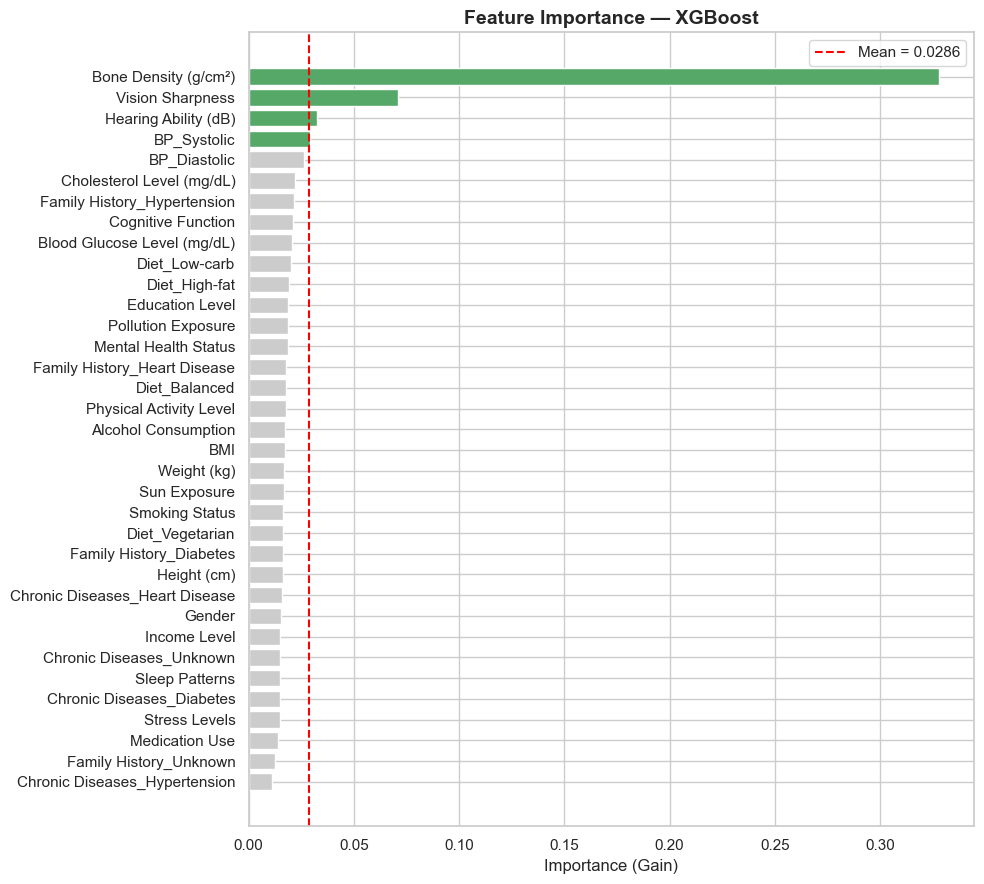

In [7]:
# Visualisasi XGBoost importance
fig, ax = plt.subplots(figsize=(10, 9))
data = xgb_imp.sort_values('importance', ascending=True)
threshold_xgb = xgb_imp['importance'].mean()
colors = ['#55A868' if v >= threshold_xgb else '#cccccc' for v in data['importance']]
ax.barh(data['feature'], data['importance'], color=colors, edgecolor='white')
ax.axvline(threshold_xgb, color='red', linestyle='--', label=f'Mean = {threshold_xgb:.4f}')
ax.set_xlabel('Importance (Gain)')
ax.set_title('Feature Importance — XGBoost', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('embedded_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Perbandingan Ranking & Pemilihan Fitur

**Threshold**: fitur terpilih jika importance ≥ rata-rata di **salah satu** model (RF atau XGBoost). Ini lebih inklusif daripada mengharuskan di atas rata-rata di kedua model, sehingga mengurangi risiko kehilangan fitur yang penting bagi satu model tapi tidak yang lain.

In [8]:
# Gabungkan ranking
combined = pd.DataFrame({'feature': X_train.columns})
rf_dict  = dict(zip(rf_imp['feature'], rf_imp['importance']))
xgb_dict = dict(zip(xgb_imp['feature'], xgb_imp['importance']))

combined['rf_importance']  = combined['feature'].map(rf_dict)
combined['xgb_importance'] = combined['feature'].map(xgb_dict)

# Fitur terpilih jika di atas rata-rata di SALAH SATU model
combined['rf_selected']  = combined['rf_importance'] >= threshold_rf
combined['xgb_selected'] = combined['xgb_importance'] >= threshold_xgb
combined['embedded_selected'] = combined['rf_selected'] | combined['xgb_selected']

embedded_features = combined[combined['embedded_selected']]['feature'].tolist()
combined = combined.sort_values('rf_importance', ascending=False)

print(f'Fitur di atas mean RF   : {combined["rf_selected"].sum()}')
print(f'Fitur di atas mean XGB  : {combined["xgb_selected"].sum()}')
print(f'Union (fitur terpilih)  : {len(embedded_features)}')
print(f'\nFitur terpilih: {embedded_features}')

Fitur di atas mean RF   : 8
Fitur di atas mean XGB  : 4
Union (fitur terpilih)  : 8

Fitur terpilih: ['Cholesterol Level (mg/dL)', 'Blood Glucose Level (mg/dL)', 'Bone Density (g/cm²)', 'Vision Sharpness', 'Hearing Ability (dB)', 'Cognitive Function', 'BP_Systolic', 'BP_Diastolic']


In [9]:
# Perbandingan dengan filter method (18 fitur dari Skenario 2)
filter_features = ['Weight (kg)', 'Cholesterol Level (mg/dL)', 'BMI',
    'Blood Glucose Level (mg/dL)', 'Bone Density (g/cm²)', 'Vision Sharpness',
    'Hearing Ability (dB)', 'Physical Activity Level', 'Smoking Status',
    'Cognitive Function', 'Sleep Patterns', 'Education Level', 'Income Level',
    'BP_Systolic', 'BP_Diastolic', 'Diet_Balanced',
    'Chronic Diseases_Hypertension', 'Family History_Heart Disease']

set_emb = set(embedded_features)
set_flt = set(filter_features)
consensus = set_emb & set_flt

print(f'Konsensus (Embedded ∩ Filter): {len(consensus)} fitur')
print(f'  → {sorted(consensus)}')
print(f'\nHanya di Embedded: {sorted(set_emb - set_flt)}')
print(f'Hanya di Filter  : {sorted(set_flt - set_emb)}')

Konsensus (Embedded ∩ Filter): 8 fitur
  → ['BP_Diastolic', 'BP_Systolic', 'Blood Glucose Level (mg/dL)', 'Bone Density (g/cm²)', 'Cholesterol Level (mg/dL)', 'Cognitive Function', 'Hearing Ability (dB)', 'Vision Sharpness']

Hanya di Embedded: []
Hanya di Filter  : ['BMI', 'Chronic Diseases_Hypertension', 'Diet_Balanced', 'Education Level', 'Family History_Heart Disease', 'Income Level', 'Physical Activity Level', 'Sleep Patterns', 'Smoking Status', 'Weight (kg)']


### Interpretasi Domain Kesehatan

**Fitur konsensus** yang muncul di Filter, Wrapper, dan Embedded:
- **Bone Density, Vision Sharpness, Hearing Ability** → penanda degenerasi fisik seiring usia, secara medis sangat relevan
- **Cognitive Function** → penurunan kognitif terutama di atas 60 tahun
- **Cholesterol, Blood Glucose, BP** → perubahan profil metabolik dan kardiovaskular

Perbedaan antar metode wajar karena:
- Filter menilai fitur **independen** dari model
- Embedded menilai fitur **dalam konteks interaksi** di dalam model
- Fitur OHE (Diet, Family History) sering dianggap kurang penting oleh tree-based models karena informasinya terfragmentasi ke banyak kolom biner

---
## 5. Latih Ulang Model dengan Fitur Embedded

In [10]:
X_train_emb = X_train[embedded_features]
X_test_emb  = X_test[embedded_features]
print(f'Shape: X_train={X_train_emb.shape}, X_test={X_test_emb.shape}')

def evaluate_model(model, X, y, name):
    y_pred = cross_val_predict(model, X, y, cv=cv)
    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, average='weighted')
    rec  = recall_score(y, y_pred, average='weighted')
    f1   = f1_score(y, y_pred, average='weighted')
    print(f'\n--- {name} ---')
    print(f'Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f}')
    print(classification_report(y, y_pred, target_names=[LABEL_NAMES[i] for i in range(4)]))
    return {'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1, 'y_pred': y_pred}

rf_res  = evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train_emb, y_train, 'Random Forest')
knn_res = evaluate_model(KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1), X_train_emb, y_train, 'KNN (k=7)')
svm_res = evaluate_model(SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42), X_train_emb, y_train, 'SVM (RBF)')

Shape: X_train=(3000, 8), X_test=(3000, 8)



--- Random Forest ---
Acc=0.8063 | Prec=0.8057 | Rec=0.8063 | F1=0.8060
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.87      0.87      0.87       726
     Dewasa (36-53)       0.74      0.75      0.74       789
 Paruh Baya (54-71)       0.74      0.72      0.73       726
     Lansia (72-89)       0.88      0.89      0.89       759

           accuracy                           0.81      3000
          macro avg       0.81      0.81      0.81      3000
       weighted avg       0.81      0.81      0.81      3000


--- KNN (k=7) ---
Acc=0.7723 | Prec=0.7711 | Rec=0.7723 | F1=0.7715
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.85      0.84      0.85       726
     Dewasa (36-53)       0.69      0.71      0.70       789
 Paruh Baya (54-71)       0.69      0.65      0.67       726
     Lansia (72-89)       0.85      0.88      0.87       759

           accuracy                           0.77      3000


--- SVM (RBF) ---
Acc=0.8103 | Prec=0.8097 | Rec=0.8103 | F1=0.8099
                     precision    recall  f1-score   support

Dewasa Muda (18-35)       0.87      0.87      0.87       726
     Dewasa (36-53)       0.75      0.76      0.75       789
 Paruh Baya (54-71)       0.75      0.72      0.73       726
     Lansia (72-89)       0.87      0.90      0.89       759

           accuracy                           0.81      3000
          macro avg       0.81      0.81      0.81      3000
       weighted avg       0.81      0.81      0.81      3000



## 6. Confusion Matrix

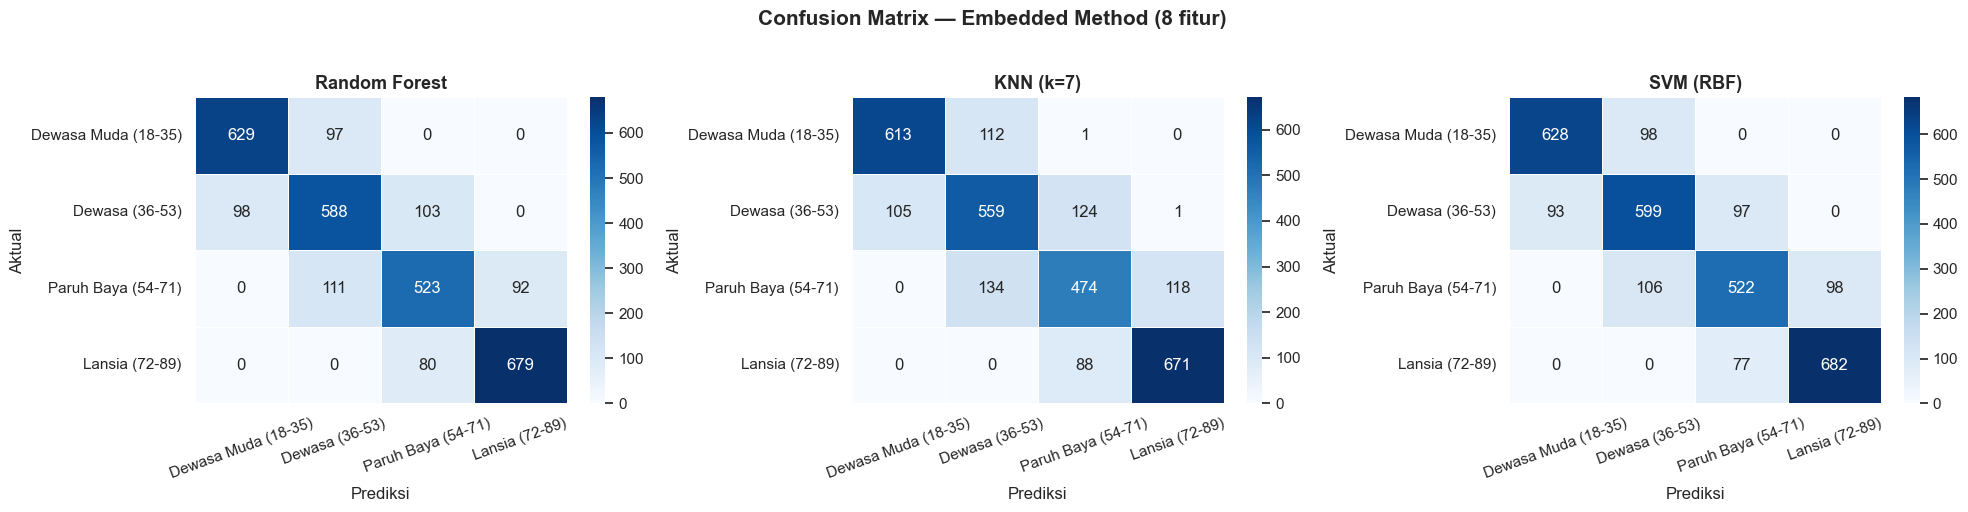

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
labels = [LABEL_NAMES[i] for i in range(4)]
for ax, res in zip(axes, [rf_res, knn_res, svm_res]):
    cm = confusion_matrix(y_train, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels,
                yticklabels=labels, linewidths=0.5, ax=ax)
    ax.set_title(res['model'], fontsize=13, fontweight='bold')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle(f'Confusion Matrix — Embedded Method ({len(embedded_features)} fitur)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('embedded_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Perbandingan Akumulatif (4 Skenario)

In [12]:
embedded_results = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [rf_res, knn_res, svm_res]
]).set_index('model')
embedded_results.to_csv('embedded_method_results.csv')

print('=' * 95)
print('PERBANDINGAN AKUMULATIF F1-SCORE — 4 SKENARIO')
print('=' * 95)
nf_emb = len(embedded_features)
header = f'{"Model":20s} | {"Baseline(35)":>13s} | {"Filter(18)":>13s} | {"Wrapper":>13s} | {"Embedded("+str(nf_emb)+")":>13s}'
print(header)
print('-' * 95)

for m in baseline.index:
    vals = [baseline.loc[m,'f1_score'], filter_res.loc[m,'f1_score'],
            wrapper_res.loc[m,'f1_score'], embedded_results.loc[m,'f1_score']]
    best = max(vals)
    marks = ['🏆' if v == best else '  ' for v in vals]
    print(f'{m:20s} | {vals[0]:>9.4f} {marks[0]} | {vals[1]:>9.4f} {marks[1]} | {vals[2]:>9.4f} {marks[2]} | {vals[3]:>9.4f} {marks[3]}')

PERBANDINGAN AKUMULATIF F1-SCORE — 4 SKENARIO
Model                |  Baseline(35) |    Filter(18) |       Wrapper |   Embedded(8)
-----------------------------------------------------------------------------------------------
Random Forest        |    0.8099    |    0.8126 🏆 |    0.8108    |    0.8060   
KNN (k=7)            |    0.6117    |    0.6939    |    0.6564    |    0.7715 🏆
SVM (RBF)            |    0.7990    |    0.8020    |    0.8056    |    0.8099 🏆


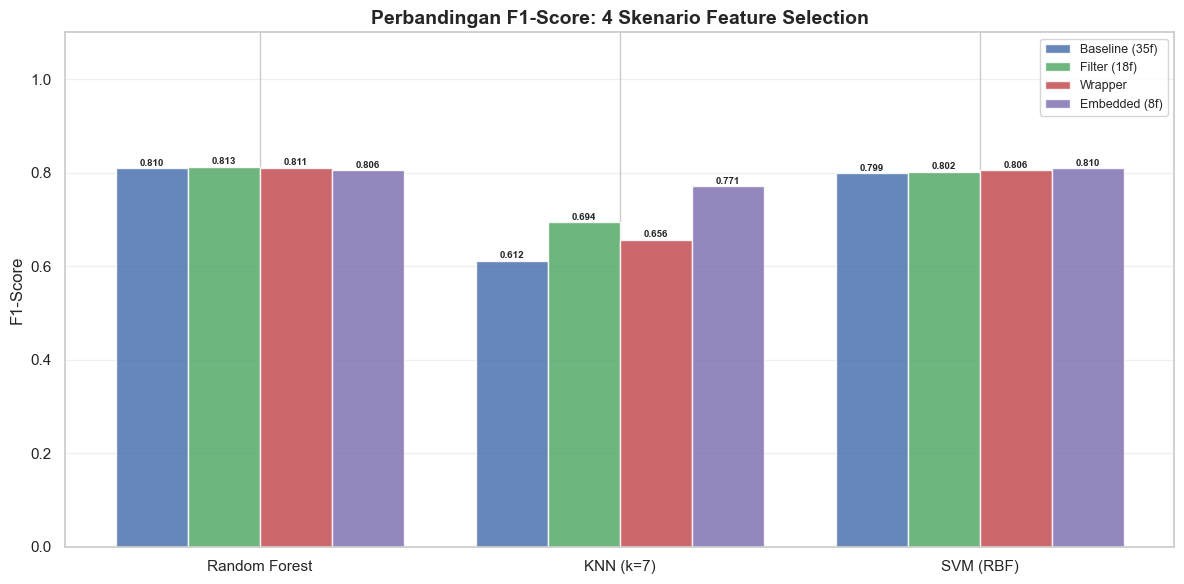

In [13]:
# Visualisasi 4 skenario
fig, ax = plt.subplots(figsize=(12, 6))
models = baseline.index.tolist()
x = np.arange(len(models))
w = 0.2
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
all_res = [
    ('Baseline (35f)', baseline), ('Filter (18f)', filter_res),
    ('Wrapper', wrapper_res), (f'Embedded ({nf_emb}f)', embedded_results)
]

for i, (label, df) in enumerate(all_res):
    vals = [df.loc[m,'f1_score'] for m in models]
    bars = ax.bar(x + i*w, vals, w, label=label, color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7, fontweight='bold')

ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(models)
ax.set_ylabel('F1-Score')
ax.set_title('Perbandingan F1-Score: 4 Skenario Feature Selection', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('embedded_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Kesimpulan Skenario 4

### Analisis: Mengapa Setiap Model Merespons Berbeda?

| Model | Karakteristik | Skenario Terbaik | Alasan |
|-------|-------------|-----------------|--------|
| **RF** | Internal feature selection via tree splits | Stabil di semua skenario | Sudah robust terhadap fitur noise karena bagging + random feature sampling |
| **KNN** | Sensitif terhadap dimensi | Filter method | Pengurangan dimensi agresif (35→18) paling membantu mengatasi curse of dimensionality |
| **SVM** | Mencari margin optimal | Wrapper/Embedded | Membutuhkan fitur yang secara kolektif mengoptimalkan margin pemisah |

### Seleksi Fitur vs Reduksi Dimensi

| Aspek | Seleksi Fitur (B.2–B.4) | Reduksi Dimensi (B.5–B.6) |
|-------|------------------------|---------------------------|
| Cara kerja | **Memilih subset** fitur asli | **Mentransformasi** fitur menjadi komponen baru |
| Interpretability | Tinggi — fitur asli dipertahankan | Rendah — komponen baru tidak punya makna fisik |
| Redundansi | Mungkin masih ada fitur redundan | Menghilangkan redundansi via orthogonalization |
| Informasi | Bisa kehilangan interaksi | Mempertahankan varians maksimal |

### Skenario Selanjutnya
- **B.5 (PCA)**: Apakah transformasi ke ruang komponen utama yang orthogonal bisa mengalahkan seleksi fitur?
- **B.6**: Metode reduksi dimensi lainnya sebagai pembanding PCA